In [1]:
# 1. IMPORTS & SETUP
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
import warnings

from IPython.display import display
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

# Notebook Configurations
%matplotlib inline
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')
print("Environment initialized.")

Environment initialized.


In [2]:
# 2. DATA LOADING & INITIAL PRUNING
print("Loading Oracle's Elixir dataset...")
file_path = "2024_LoL_esports_match_data_from_OraclesElixir1.csv" # Ensure this matches your file name!

raw_df = pd.read_csv(file_path, sep=';', low_memory=False)

# Drop columns that provide zero mathematical value
useless_columns = ['url', 'league', 'year', 'split', 'date', 'patch', 'playerid', 'teamid']
df = raw_df.drop(columns=[col for col in useless_columns if col in raw_df.columns])

print(f"Working Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

Loading Oracle's Elixir dataset...
Working Dataset Shape: 12276 rows and 115 columns


In [3]:
# 3. TYPE A PREPROCESSING: 15-Minute Game State (No Leakage Risk)
print("Engineering 15-Minute Game State...")

teams = df[df['position'] == 'team'].copy()
teams['golddiffat15'] = pd.to_numeric(teams['golddiffat15'], errors='coerce')
teams = teams.dropna(subset=['golddiffat15'])

teams['platediff'] = pd.to_numeric(teams['turretplates'], errors='coerce') - pd.to_numeric(teams['opp_turretplates'], errors='coerce')

kills = pd.to_numeric(teams['killsat15'], errors='coerce')
assists = pd.to_numeric(teams['assistsat15'], errors='coerce')
deaths = pd.to_numeric(teams['deathsat15'], errors='coerce')
teams['kda_15'] = (kills + assists) / (deaths + 1)

teams['side_encoded'] = teams['side'].map({'Blue': 1, 'Red': 0})
print(f"Engineered Phase 1 features for {teams.shape[0]} team instances.")

Engineering 15-Minute Game State...
Engineered Phase 1 features for 1672 team instances.


In [4]:
# 4. THE TRAIN/TEST BOUNDARY & DRAFT ADVANTAGE
print("Splitting data to protect against Data Leakage...")

train_teams, test_teams = train_test_split(teams, test_size=0.2, random_state=42)
train_game_ids = train_teams['gameid'].unique()

players_df = df[df['position'] != 'team'].copy()
train_players = players_df[players_df['gameid'].isin(train_game_ids)]

train_champ_win_rates = train_players.groupby('champion')['result'].mean().to_dict()

def engineer_draft(team_subset, player_subset, win_rates):
    p_sub = player_subset[player_subset['gameid'].isin(team_subset['gameid'])].copy()
    p_sub['champ_winrate'] = p_sub['champion'].map(win_rates).fillna(0.5)
    
    draft_feats = p_sub.pivot(index=['gameid', 'side'], columns='position', values='champ_winrate').reset_index()
    draft_feats['team_draft_strength'] = draft_feats[['top', 'jng', 'mid', 'bot', 'sup']].mean(axis=1)
    
    opp_draft = draft_feats[['gameid', 'side', 'team_draft_strength']].copy()
    opp_draft['side'] = opp_draft['side'].map({'Blue': 'Red', 'Red': 'Blue'})
    opp_draft.rename(columns={'team_draft_strength': 'opp_draft_strength'}, inplace=True)
    
    final_draft = pd.merge(draft_feats, opp_draft, on=['gameid', 'side'])
    final_draft['draft_adv'] = final_draft['team_draft_strength'] - final_draft['opp_draft_strength']
    
    return pd.merge(team_subset, final_draft[['gameid', 'side', 'draft_adv']], on=['gameid', 'side'])

train_master = engineer_draft(train_teams, players_df, train_champ_win_rates)
test_master = engineer_draft(test_teams, players_df, train_champ_win_rates)
print("Target Encoding Complete! No Data Leakage detected.")

Splitting data to protect against Data Leakage...
Target Encoding Complete! No Data Leakage detected.


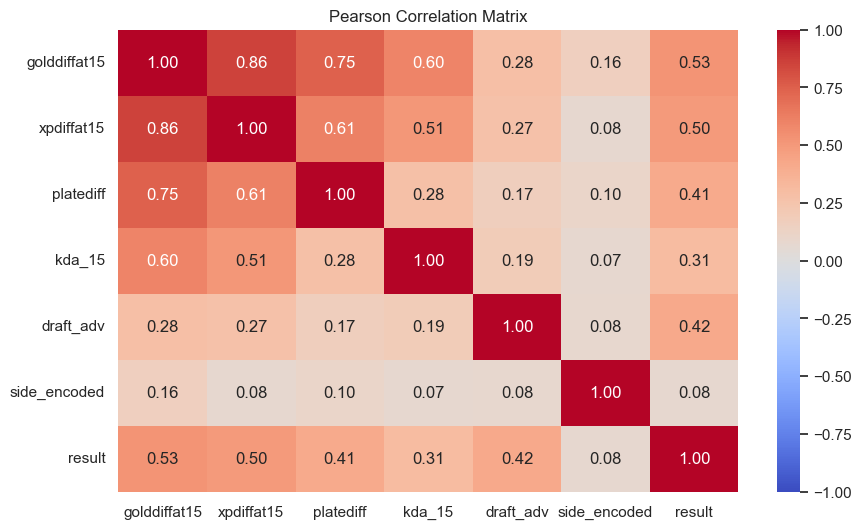

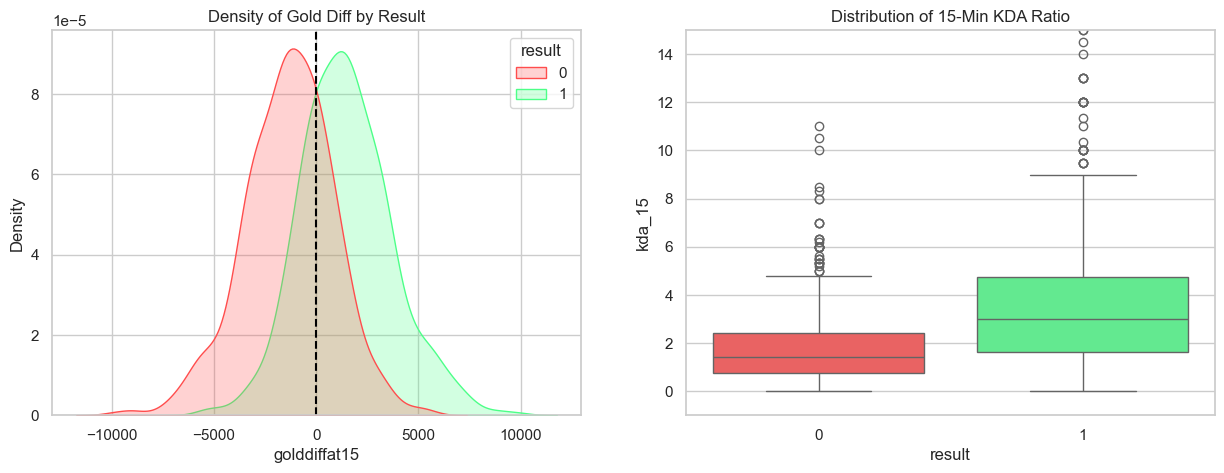

In [5]:
# 5. EXPLORATORY DATA ANALYSIS (EDA)
features = ['golddiffat15', 'xpdiffat15', 'platediff', 'kda_15', 'draft_adv', 'side_encoded']
for col in features + ['result']:
    train_master[col] = pd.to_numeric(train_master[col], errors='coerce')

# Plot 1: The Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(train_master[features + ['result']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Pearson Correlation Matrix')
plt.show()

# Plot 2: Density and Boxplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.kdeplot(data=train_master, x='golddiffat15', hue='result', fill=True, palette=['#ff4d4d', '#4dff88'], ax=axes[0])
axes[0].set_title('Density of Gold Diff by Result')
axes[0].axvline(0, color='black', linestyle='--')

sns.boxplot(data=train_master, x='result', y='kda_15', palette=['#ff4d4d', '#4dff88'], ax=axes[1])
axes[1].set_title('Distribution of 15-Min KDA Ratio')
axes[1].set_ylim(-1, 15)
plt.show()

In [6]:
# 6. FEATURE SCALING
X_train = train_master[features].fillna(0)
y_train = train_master['result']
X_test = test_master[features].fillna(0)
y_test = test_master['result']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Matrix ready. Training instances: {X_train_scaled.shape[0]}")

Matrix ready. Training instances: 1337


In [7]:
# 7. BASELINE LINEAR MODELING
print("--- Baseline Models ---")
baseline_models = {
    "Logistic Regression": LogisticRegression(),
    "Support Vector Machine": SVC(kernel='linear', probability=True, random_state=42)
}

for name, model in baseline_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"{name:25} | Accuracy: {accuracy_score(y_test, y_pred):.3f} | F1: {f1_score(y_test, y_pred):.3f}")

--- Baseline Models ---
Logistic Regression       | Accuracy: 0.764 | F1: 0.761
Support Vector Machine    | Accuracy: 0.761 | F1: 0.758


In [8]:
# 8. ADVANCED MODELING & HYPERPARAMETER TUNING
print("--- Advanced Models (Untuned) ---")
advanced_models = {
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}

for name, model in advanced_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"{name:25} | Accuracy: {accuracy_score(y_test, y_pred):.3f} | F1: {f1_score(y_test, y_pred):.3f}")

print("\n--- Hyperparameter Tuning (Random Forest) ---")
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
best_rf = grid_search.best_estimator_

tuned_y_pred = best_rf.predict(X_test_scaled)
print(f"Tuned Random Forest       | Accuracy: {accuracy_score(y_test, tuned_y_pred):.3f} | F1: {f1_score(y_test, tuned_y_pred):.3f}")

# Export Pipeline Assets
os.makedirs('models', exist_ok=True)
joblib.dump(best_rf, 'models/rf_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(train_champ_win_rates, 'models/champ_win_rates.pkl')
print("\nSuccess! Exported rf_model.pkl, scaler.pkl, and champ_win_rates.pkl to /models")

--- Advanced Models (Untuned) ---
Gradient Boosting         | Accuracy: 0.746 | F1: 0.738
AdaBoost                  | Accuracy: 0.758 | F1: 0.754
Neural Network (MLP)      | Accuracy: 0.710 | F1: 0.709

--- Hyperparameter Tuning (Random Forest) ---
Tuned Random Forest       | Accuracy: 0.761 | F1: 0.758

Success! Exported rf_model.pkl, scaler.pkl, and champ_win_rates.pkl to /models
